#World Layoffs — Exploratory Data Analysis with Python

Analyzing global layoff trends, companies, industries, and countries using Pandas and Matplotlib.

## 1. Load the Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving layoffs.csv to layoffs (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("layoffs.csv")

In [ ]:
df.shape

(2361, 9)

## 2. Initial Data Exploration

In [ ]:
df.shape

(2361, 9)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2361 entries, 0 to 2360
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company                2361 non-null   object 
 1   location               2361 non-null   object 
 2   industry               2357 non-null   object 
 3   total_laid_off         1621 non-null   float64
 4   percentage_laid_off    1576 non-null   float64
 5   date                   2360 non-null   object 
 6   stage                  2355 non-null   object 
 7   country                2361 non-null   object 
 8   funds_raised_millions  2152 non-null   float64
dtypes: float64(3), object(6)
memory usage: 166.1+ KB


In [ ]:
df.columns


Index(['company', 'location', 'industry', 'total_laid_off',
       'percentage_laid_off', 'date', 'stage', 'country',
       'funds_raised_millions'],
      dtype='object')

In [ ]:
df.describe()


,total_laid_off,percentage_laid_off,funds_raised_millions
count,1621.000000,1576.000000,2152.000000
mean,238.358421,0.257917,822.454134
std,769.718801,0.255575,5593.961626
min,3.000000,0.000000,0.000000
25%,36.000000,0.100000,50.000000
50%,80.000000,0.170000,156.500000
75%,180.000000,0.300000,445.000000
max,12000.000000,1.000000,121900.000000


In [ ]:
df["company"].value_counts().head(10)


,count
company,
Loft,6
Swiggy,5
OYO,5
Uber,5
Shopify,4
Vedantu,4
Twitter,4
Better.com,4
Convoy,4


In [ ]:

df.loc[df["total_laid_off"].idxmax()]

,281
company,Google
location,SF Bay Area
industry,Consumer
total_laid_off,12000.0
percentage_laid_off,0.06
date,1/20/2023
stage,Post-IPO
country,United States
funds_raised_millions,26.0


In [ ]:
df["country"].value_counts().head(10)


,count
country,
United States,1541
India,148
Canada,99
Brazil,77
United Kingdom,74
Germany,68
Israel,56
Australia,54
Singapore,34


In [ ]:
df.groupby("country")["total_laid_off"].sum().sort_values(ascending=False).head(10)

,total_laid_off
country,
United States,256474.0
India,35993.0
Netherlands,17220.0
Sweden,11264.0
Brazil,10691.0
Germany,8701.0
United Kingdom,7148.0
Canada,6319.0
Singapore,5995.0


In [ ]:
df.groupby("industry")["total_laid_off"].sum().sort_values(ascending=False).head(10)

,total_laid_off
industry,
Consumer,46682.0
Retail,43613.0
Other,36289.0
Transportation,31998.0
Finance,28344.0
Healthcare,25953.0
Food,22855.0
Real Estate,17565.0
Travel,17129.0


## 3. Data Cleaning

In [ ]:
df.duplicated().sum()

np.int64(5)

In [ ]:
df[df.duplicated()]

,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions
1492,Cazoo,London,Transportation,750.0,0.15,6/7/2022,Post-IPO,United Kingdom,2000.0
2357,Yahoo,SF Bay Area,Consumer,1600.0,0.20,2/9/2023,Acquired,United States,6.0
2358,Hibob,Tel Aviv,HR,70.0,0.30,3/30/2020,Series A,Israel,45.0
2359,Casper,New York City,Retail,NaN,NaN,9/14/2021,Post-IPO,United States,339.0
2360,Wildlife Studios,Sao Paulo,Consumer,300.0,0.20,11/28/2022,Unknown,Brazil,260.0


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(2356, 9)

In [ ]:
df.isnull().sum()

,0
company,0
location,0
industry,4
total_laid_off,739
percentage_laid_off,784
date,1
stage,6
country,0
funds_raised_millions,209


In [ ]:
df[df["date"].isnull()]


,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions
2356,Blackbaud,Charleston,Other,500.0,0.14,NaN,Post-IPO,United States,NaN


In [ ]:
df = df.dropna(subset=["date"])

In [ ]:
df[df["industry"].isnull()]

,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions
8,Airbnb,SF Bay Area,NaN,30.0,NaN,3/3/2023,Post-IPO,United States,6400.0
330,Bally's Interactive,Providence,NaN,NaN,0.15,1/18/2023,Post-IPO,United States,946.0
736,Juul,SF Bay Area,NaN,400.0,0.30,11/10/2022,Unknown,United States,1500.0
1595,Carvana,Phoenix,NaN,2500.0,0.12,5/10/2022,Post-IPO,United States,1600.0


In [ ]:
df = df.dropna(subset=["industry"])

In [ ]:
df.shape

(2351, 9)

In [ ]:
df[df["stage"].isnull()]

,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions
392,Verily,SF Bay Area,Healthcare,250.0,0.15,1/11/2023,NaN,United States,3500.0
414,Relevel,Bengaluru,HR,40.0,0.20,1/10/2023,NaN,India,NaN
831,Advata,Seattle,Healthcare,32.0,0.21,10/28/2022,NaN,United States,NaN
837,Spreetail,Austin,Retail,NaN,NaN,10/27/2022,NaN,United States,NaN
1183,Gatherly,Atlanta,Marketing,NaN,0.50,7/31/2022,NaN,United States,NaN
1565,Zapp,London,Food,NaN,0.10,5/25/2022,NaN,United Kingdom,300.0


In [ ]:
df = df.dropna(subset=["stage"])

In [ ]:
df.shape

(2345, 9)

In [ ]:
df["total_laid_off"].isnull().sum()

np.int64(735)

In [ ]:
df[df["total_laid_off"].isnull() & df["percentage_laid_off"].notnull()]

,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions
17,Kandela,Los Angeles,Consumer,NaN,1.00,3/2/2023,Acquired,United States,NaN
26,Protego Trust Bank,Seattle,Crypto,NaN,0.50,3/1/2023,Series A,United States,70.0
29,DUX Education,Bengaluru,Education,NaN,1.00,2/28/2023,Unknown,India,NaN
30,MeridianLink,Los Angeles,Finance,NaN,0.09,2/28/2023,Post-IPO,United States,485.0
46,Poshmark,SF Bay Area,Retail,NaN,0.02,2/24/2023,Acquired,United States,153.0
...,...,...,...,...,...,...,...,...,...
2332,Cabin,SF Bay Area,Travel,NaN,0.20,3/23/2020,Seed,United States,3.0
2333,Eight Sleep,New York City,Retail,NaN,0.20,3/23/2020,Series C,United States,70.0
2339,Service,Los Angeles,Travel,NaN,1.00,3/20/2020,Seed,United States,5.0
2346,Popin,New York City,Fitness,NaN,1.00,3/19/2020,Unknown,United States,13.0


In [ ]:
df[df["total_laid_off"].isnull() & df["percentage_laid_off"].isnull()].shape

(360, 9)

In [ ]:
df = df.dropna(subset=["total_laid_off", "percentage_laid_off"], how="all")

In [ ]:
df.shape

(1985, 9)

In [ ]:
df.isnull().sum()

,0
company,0
location,0
industry,0
total_laid_off,375
percentage_laid_off,422
date,0
stage,0
country,0
funds_raised_millions,161


In [ ]:
df[df["funds_raised_millions"].isnull()].head(10)

,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions
13,Ambev Tech,Blumenau,Food,50.0,NaN,3/2/2023,Acquired,Brazil,NaN
17,Kandela,Los Angeles,Consumer,NaN,1.00,3/2/2023,Acquired,United States,NaN
29,DUX Education,Bengaluru,Education,NaN,1.00,2/28/2023,Unknown,India,NaN
47,Merative,Ann Arbor,Healthcare,200.0,0.10,2/23/2023,Acquired,United States,NaN
49,The Iconic,Sydney,Retail,69.0,0.06,2/23/2023,Unknown,Australia,NaN
54,Vibrent Health,Washington D.C.,Healthcare,NaN,0.13,2/23/2023,Unknown,United States,NaN
55,Synamedia,London,Media,200.0,0.12,2/22/2023,Unknown,United Kingdom,NaN
64,Bolt,Lagos,Transportation,17.0,NaN,2/21/2023,Series F,Nigeria,NaN
98,CommerceHub,Albany,Retail,371.0,0.31,2/14/2023,Acquired,United States,NaN
104,EMX Digital,New York City,Marketing,100.0,1.00,2/13/2023,Unknown,United States,NaN


In [ ]:
df["date"] = pd.to_datetime(df["date"])

In [ ]:
df.dtypes

,0
company,object
location,object
industry,object
total_laid_off,float64
percentage_laid_off,float64
date,datetime64[ns]
stage,object
country,object
funds_raised_millions,float64


## 4. Exploratory Data Analysis

In [ ]:
df.groupby(df["date"].dt.year)["total_laid_off"].sum()

,total_laid_off
date,
2020,80998.0
2021,15823.0
2022,157729.0
2023,125357.0


<Axes: title={'center': 'Total Layoffs by Year'}, xlabel='Year', ylabel='Employees Laid Off'>

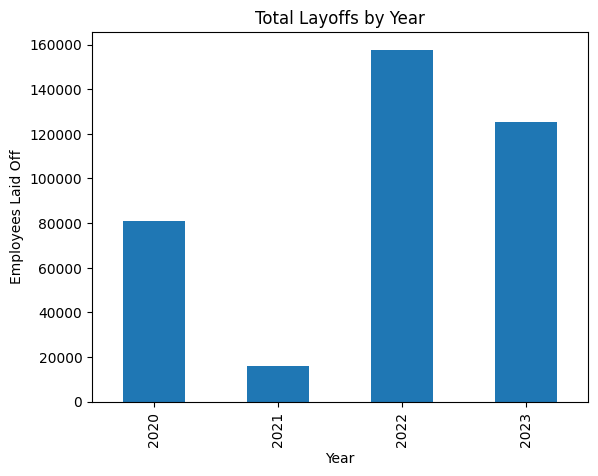

In [ ]:
df.groupby(df["date"].dt.year)["total_laid_off"].sum().plot(
    kind="bar",
    title="Total Layoffs by Year",
    xlabel="Year",
    ylabel="Employees Laid Off"
)

In [ ]:
df.groupby("company")["total_laid_off"].sum().sort_values(ascending=False).head(10)

,total_laid_off
company,
Amazon,18150.0
Google,12000.0
Meta,11000.0
Salesforce,10090.0
Philips,10000.0
Microsoft,10000.0
Ericsson,8500.0
Uber,7585.0
Dell,6650.0


<Axes: title={'center': 'Top 10 Companies by Total Layoffs'}, xlabel='Company', ylabel='Employees Laid Off'>

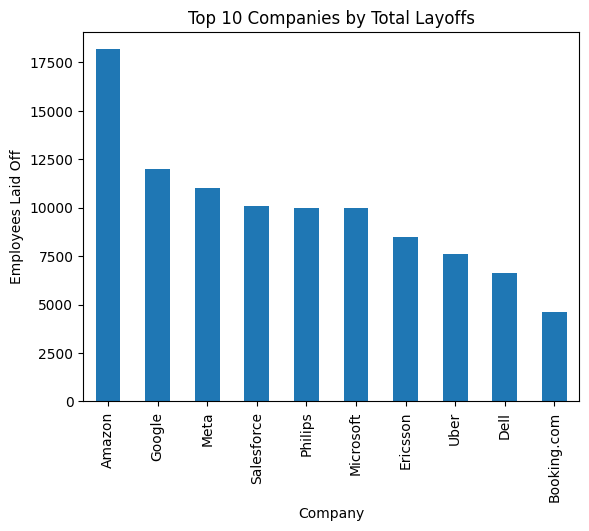

In [ ]:
df.groupby("company")["total_laid_off"].sum().sort_values(ascending=False).head(10).plot(
    kind="bar",
    title="Top 10 Companies by Total Layoffs",
    xlabel="Company",
    ylabel="Employees Laid Off"
)

In [ ]:
df.groupby("country")["total_laid_off"].sum().sort_values(ascending=False).head(10)

,total_laid_off
country,
United States,255692.0
India,35953.0
Netherlands,17220.0
Sweden,11264.0
Brazil,10691.0
Germany,8701.0
United Kingdom,7148.0
Canada,6319.0
Singapore,5995.0


<Axes: title={'center': 'Top 10 Countries by Total Layoffs'}, xlabel='Country', ylabel='Employees Laid Off'>

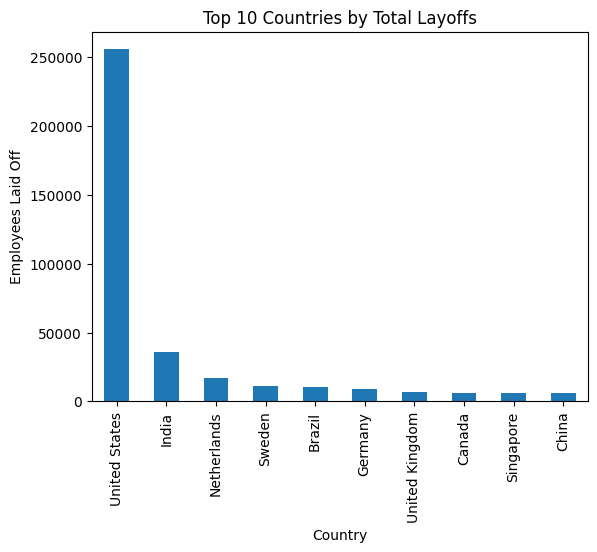

In [ ]:
df.groupby("country")["total_laid_off"].sum().sort_values(ascending=False).head(10).plot(
    kind="bar",
    title="Top 10 Countries by Total Layoffs",
    xlabel="Country",
    ylabel="Employees Laid Off"
)

In [ ]:
df.groupby("industry")["total_laid_off"].sum().sort_values(ascending=False).head(10)

,total_laid_off
industry,
Consumer,46682.0
Retail,43613.0
Other,35789.0
Transportation,31998.0
Finance,28344.0
Healthcare,25671.0
Food,22855.0
Real Estate,17565.0
Travel,17129.0


<Axes: title={'center': 'Top 10 Industries by Total Layoffs'}, xlabel='Industry', ylabel='Employees Laid Off'>

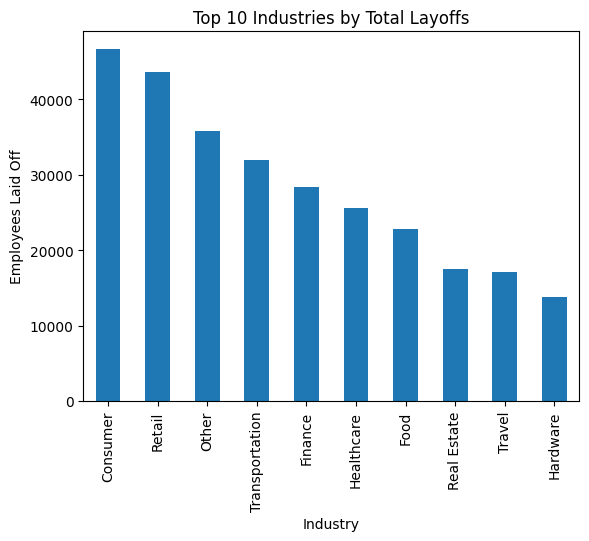

In [ ]:
df.groupby("industry")["total_laid_off"].sum().sort_values(ascending=False).head(10).plot(
    kind="bar",
    title="Top 10 Industries by Total Layoffs",
    xlabel="Industry",
    ylabel="Employees Laid Off"
)

In [ ]:
df.groupby("company")["percentage_laid_off"].max().sort_values(ascending=False).head(10)

,percentage_laid_off
company,
YourGrocer,1.0
Hubba,1.0
HubHaus,1.0
Arch Oncology,1.0
Ahead,1.0
Amplero,1.0
Pastel,1.0
Pesto,1.0
Perceptive Automata,1.0


In [ ]:
df.groupby("industry")["percentage_laid_off"].mean().sort_values(ascending=False).head(10)

,percentage_laid_off
industry,
Aerospace,0.565000
Education,0.357407
Travel,0.349091
Food,0.325655
Recruiting,0.323333
Real Estate,0.317308
Fitness,0.305714
Crypto,0.294177
Infrastructure,0.288000


In [ ]:
df.groupby(df["date"].dt.to_period("M"))["total_laid_off"].sum().sort_index()

,total_laid_off
date,
2020-03,9698.0
2020-04,26710.0
2020-05,25804.0
2020-06,7627.0
2020-07,7112.0
2020-08,1969.0
2020-09,609.0
2020-10,450.0
2020-11,237.0


<Axes: title={'center': 'Layoffs Over Time'}, xlabel='Month', ylabel='Employees Laid Off'>

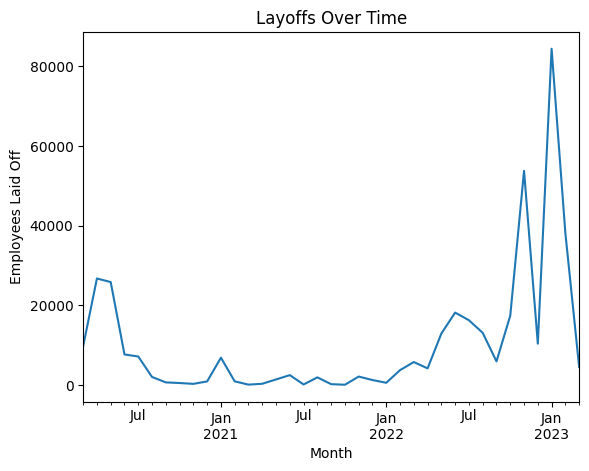

In [ ]:
df.groupby(df["date"].dt.to_period("M"))["total_laid_off"].sum().sort_index().plot(
    kind="line",
    title="Layoffs Over Time",
    xlabel="Month",
    ylabel="Employees Laid Off"
)

In [ ]:
df.groupby("company")["funds_raised_millions"].max().sort_values(ascending=False).head(10)

,funds_raised_millions
company,
Netflix,121900.0
Meta,26000.0
Uber,24700.0
WeWork,22200.0
Tesla,20200.0
WeWork,19500.0
Twitter,12900.0
Tencent,12600.0
Rivian,10700.0


In [ ]:
df["company"].value_counts().head(10)

,count
company,
Loft,6
Swiggy,5
Uber,5
Latch,4
Shopify,4
Vedantu,4
Salesforce,4
Patreon,4
Gopuff,4


In [ ]:
df["total_laid_off"].sum()

np.float64(379907.0)

In [ ]:
df.shape

(1985, 9)

## 5. Key Findings

- Global layoffs peaked in **2022**, with approximately **157,729 employees laid off**.
- **Amazon** recorded the highest total layoffs among companies, with **18,150 employees**.
- Layoffs fluctuated significantly between **2020 and 2023**, with 2022 being the most severe year.
- The analysis contains **1,985 cleaned records** across multiple countries, industries, and company stages.
- The dataset records approximately **379,907 total layoffs** across the analyzed period.